## Automated Quantum Circuits from Logical Connectives csd3974

### Setting up

In [2]:
import qiskit
from qiskit_ibm_runtime import QiskitRuntimeService
import numpy as np
from collections import Counter
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister


### Part 1: Truth table and logical connective of a small example
| s | ψ(s) | p | ψ(p) | o | ψ(o)
| --- | --- | --- | --- | --- | --- |
| ex:Aristotle | 2 | rdf:type | 0 | ex:Person | 3 |
| ex:Person | 3 | rdfs:subClassOf | 1 | ex:Mortal | 4 |
| ex:Aristotle | 2 | ex:livesAt | 5 | ex:Athens | 6 |

Focusing on  fP→O

ψ(p) | ψ(o) 
| --- | --- |
| 0 | 3 |
| 1 | 4 |
| 5 | 6 |

Bitwise

| a0 | a1 | a2 | b0 | b1 | b2 |
| --- | --- | --- | --- | --- | --- |
| 0 | 0 | 0 | 0 | 1 | 1 |
| 0 | 0 | 1 | 1 | 0 | 0 |
| 1 | 0 | 1 | 1 | 1 | 0 |


$$
  b0 =  (\lnot a0 \land \lnot a1 \land a2) \lor (a0 \land \lnot a1 \land a2) \\ 
  b1 = (\lnot a0 \land \lnot a1 \land \lnot a2) \lor (a0 \land \lnot a1 \land a2) \\
  b2 = \lnot a0 \land \lnot a1 \land \lnot a2 \\
$$

### Part 2: Implement Younes-Miller (2003) method to create Quantum Circuits

In our example, we will create a circuit with a 3-bit input and a 3-bit output. The bitsize will be scalable to our needs.
To do that we need to find the 3-bit inputs that make b0,b1,b2 true. We did that step above.
To summarize 

b0 will be true with the input (0,0,1) or (0,1,1) 

b1 will be true with the input (0,0,0) or (1,0,1) 

b2 will be true with the input (0,0,0) 


Now we will follow the algorithm of Younes-Miller to create the appropriate gates

### Stage 1

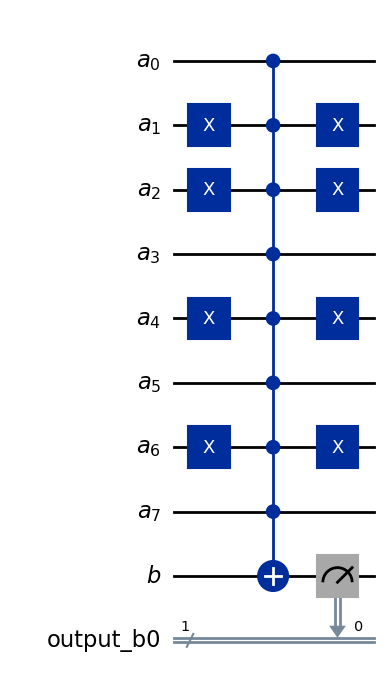

In [15]:

# Step 1: Select the input configurations from the truth table where each b in is 1.

# Then create a quantum circuit with 3 qubits for a0, a1, a2 and 3 target qubits for b0,b1,b3
# The input is given in a form of [[(a0,a1,a2) for b0=1], [(a0,a1,a2) for b1=1], [(a0,a1,a2) for b2=1]].

inputSize = 8
outputSize = 1
#conf = [[(1,0,1),(0,1,0),(1,1,1)]]
conf = [[(1,0,0,1,0,1,0,1)]]
#conf = [[(0,0,0),(0,0,1),(0,1,0),(1,1,1),(0,1,1)]] #Younes-Miller example from the paper
#conf = [[(1,0,1)]]
#conf = [[(1,0,1,1,1,1,1,1,1,1,1,0,0,1,1,1,0,1,1,0,1,1,1,1,1,0,0,1)]]



a = QuantumRegister(inputSize, 'a')
b = QuantumRegister(outputSize, 'b')
qc = QuantumCircuit(a, b)
c = ClassicalRegister(1, 'output_b0')
qc.add_register(c)

outputCounter = 0
# Step 2: Add a single CNOT gate for every selected configuration taking the correct bi as the target qubit.
# Set the condition on the control qubit for gates being added according
# to its value in the configuration from the truth table, i.e. the qubit with
# value 0 in the truth table will be set to cond-0 in the corresponding CNOT
# gate and the qubit with value 1 will be set to cond-1 in the corresponding
# CNOT gate. In our case we do that with X gates before and after the CNOT gate.

for c in conf:
    for input in c:
        for i in range(inputSize):
            if input[i] == 0:
                qc.x(a[i]) ## Setting the qubit to cond-0

        qc.mcx(a,b[outputCounter]) ## Linking all control qubits to target b0

        for i in range(inputSize): 
            if input[i] == 0:
                qc.x(a[i]) ## Resetting the qubits to original state
    qc.measure(b[outputCounter], outputCounter)
    outputCounter += 1

# Step 3: Add a measurement to see the output on each bi 

qc.draw(output='mpl')


### Stage 2

17


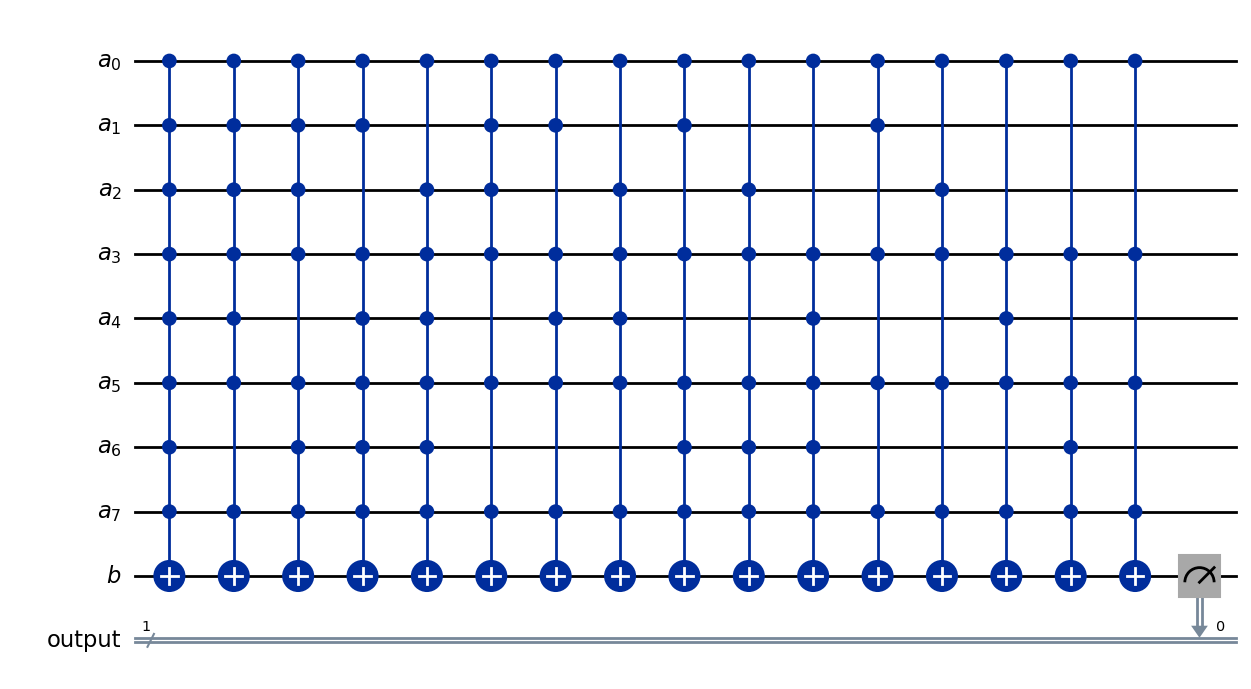

In [16]:
# Now we will improve the above idea by removing the X gates completely
# The idea is that we replace the cond0 qubits with cond1 logical equivalents
# For every single cond0 and for every combination of cond0 qubits we will
# create a multi-controlled NOT gate with the remaining cond1 qubits as controls
# In the beginning it will extend our circuit by a lot but it will help us
# simplify it in the final stage
from itertools import combinations
cond0 = []
all0 = 0
qcStage2 = QuantumCircuit(a, b)
outputCounter = 0

c_2 = ClassicalRegister(1, 'output')
qcStage2.add_register(c_2)



for c in conf:
    for input in c:
        if all(input[i] == 0 for i in range(inputSize)): # If all inputs are 0 we require a NOT gate in the end
            all0 = 1
        cond0= []
        for i in range(inputSize):
            if input[i] == 0:
                cond0.insert(0,i)  # Storing the cond0 qubits
        for i in range(0, len(cond0)+1) : # For every combination of cond0 qubits
                for combo in combinations(cond0, i):
                    controls = [a[j] for j in range(inputSize) if j not in combo]
                    if len(controls) != 0:
                        qcStage2.mcx(controls, b[outputCounter])
    if all0 == 1: 
        qcStage2.x(b[outputCounter])   # Adding the NOT gate 
        all0 = 0 # Resetting the flag
    qcStage2.measure(b[outputCounter], 0) # Measuring the output
    cond0.clear() # Resetting the cond0 list for the next input

    if(outputSize > 1):
        outputCounter += 1
        


print(qcStage2.depth())
qcStage2.draw(output='mpl')           



### Stage 3: Minimization (and final Algorithm)
In order to adapt the above idea into an editable version we are going to store the controls into a data structure. Then we can minimize the controls required for the final equivalent circuit.

In [17]:


gates = 0


def minimizeAndGenerate(qc: QuantumCircuit,outputCounter,all0,controlsArray): # Function to minimize the number of AND gates, generate and add them to the circuit
    unique = [] # List to store unique control combinations
    global gates
    counter = Counter(tuple(c) for c in controlsArray) 
    unique = [list(k) for k, v in counter.items() if v % 2 != 0] #Keeping only the gates that appear odd number of times since the even ones cancel out

    for u in unique:
        controls = [a[j] for j in range(inputSize) if u[j] == 1] # Getting the control qubits from the unique combinations
        if len(controls)!=0:
            qc.mcx(controls, b[outputCounter]) # Adding the controls to the circuit
            gates += 1
    if all0 == 1:
        qc.x(b[outputCounter]) # Adding the NOT gate if required
        gates += 1
    qc.measure(b[outputCounter], outputCounter) # Measuring the output
    controlsArray.clear() # Resetting the controls array for the next input
    unique.clear() # Resetting the unique list for the next input


def YounesMillerCircuit(qc: QuantumCircuit,conf,inputSize,outputSize):
    all0 = 0 
    cond0 = []
    controlsArray = []
    outputCounter = 0
    for c in conf:
        for input in c:
            if all(input[i] == 0 for i in range(inputSize)): # If all inputs are 0 we require a NOT gate in the end
                all0 = 1
            cond0= []
            for i in range(inputSize):
                if input[i] == 0:
                    cond0.insert(0,i)                           # Storing the cond0 qubits
            for i in range(0, len(cond0)+1):
                    for combo in combinations(cond0, i):
                        column = [1] * len(input)                   # Initializing a column with all 1s
                        for j in combo:
                            column[j] = 0                   # Setting the cond0 qubits to 0
                        controlsArray.append(column)                # Appending the column to the controls array
        
        minimizeAndGenerate(qc,outputCounter,all0,controlsArray) # Calling the minimizer function that will also add the gates to the circuit
        all0 = 0 # Resetting the all 0 flag for the next input set
        if(outputSize > 1): 
            outputCounter += 1
    return qc


a = QuantumRegister(inputSize, 'a')
b = QuantumRegister(outputSize, 'b')
qc = QuantumCircuit(a, b)
c = ClassicalRegister(outputSize, 'output_b0')
qc.add_register(c)


qc = YounesMillerCircuit(qc,conf,inputSize,outputSize)
print(qc.depth())
#qc.draw(output='mpl')  


17


## Part 3: Running tests

### Aer Simulator

In small scale examples we can use the Qiskit Aer simulator to verify the correctness of our circuit.
As previously mentioned in the papers, the Younes-Miller circuit does not take advantage of the superposition, therefore
it works deterministically (no noise) just like a classical circuit. Because of that, we are able to simulate it classically and
avoid the delay Aer Simulator causes.


Output: {'0': 1}


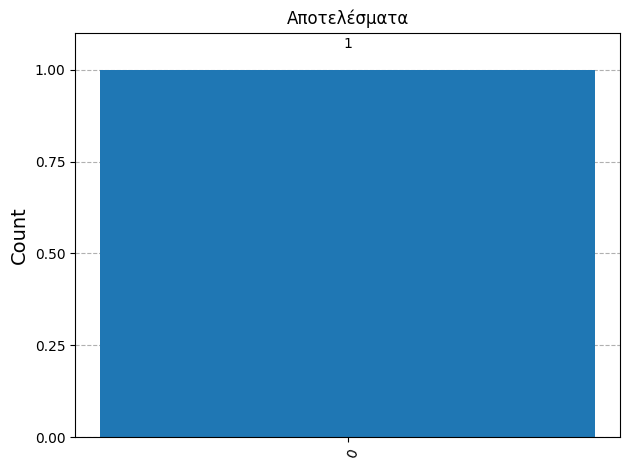

In [14]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram




sim = Aer.get_backend("aer_simulator")
tqc = transpile(qc, sim)

result = sim.run(tqc, shots=1).result()
counts = result.get_counts()

print("Output:", counts)
qc.draw(output='mpl')  
plot_histogram(counts, title='Αποτελέσματα')


### Classical Simulation

The logic of our circuit is based on XOR of CNOT Gates which is easily simulated classically by the following code.
This way we are able to test and use our circuits in larger scales than with the Aer Simulator which is made to simulate superposition.

In [9]:

import time

qc.measure_all()

SUPPORTED_GATES = {
    "x", "cx", "ccx", "mcx", "mcx_gray", "mcx_recursive", "mcx_vchain" ## All versions of controlled not gates 
}

# I used GPT 5.0 to understand the structure of qc.data and translate it into gates for classical run
def runClassically(qc: QuantumCircuit, inputs, outputs, return_counts=False):
    if len(qc.qregs) != 2:
        raise ValueError(
            f"Expected 2 quantum registers (inputs/outputs), got {len(qc.qregs)}."
        )

    qin, qout = qc.qregs
    n_in, n_out = len(qin), len(qout)

    # Incorrect argument check
    if len(inputs) != n_in or len(outputs) != n_out:
        raise ValueError(
            f"Input/output lengths must match register sizes "
            f"({n_in} / {n_out}), got ({len(inputs)} / {len(outputs)})."
        )

    # Total amount of bits
    bits = inputs + outputs
    qindex = {q: i for i, q in enumerate(qc.qubits)}
    creg_values = {} 

    # Traversing through each gate and modifying the target if the condition is satisfied
    for gate in qc.data:
        op = gate.operation
        name = op.name

        # Skip barriers and delays
        if name in {"barrier", "id", "delay"}:
            continue

        # Measurement handling
        if name == "measure":
            q = gate.qubits[0]
            c = gate.clbits[0]
            creg_values[c] = bits[qindex[q]]
            continue

        # Gates
        if name not in SUPPORTED_GATES:
            raise ValueError(f"Unsupported gate: {name}")

        qubits = [qindex[q] for q in gate.qubits]

        if name == "x":
            bits[qubits[0]] ^= 1 # Flipping the value of the qubit
        else:
            controls, target = qubits[:-1], qubits[-1] # :-1 means that we take all qubits except the last one since the last one is the target
            if all(bits[c] for c in controls):
                bits[target] ^= 1 # Flipping the targetted bit

    # Storing the final measurments
    final_inputs = bits[:n_in]
    final_outputs = bits[n_in:]

    return final_inputs, final_outputs


inputs  = [1,0,1] #Edit your input here
outputs = [0]*1   #Edit the output size here

start_time = time.time()

final_inputs, final_outputs = runClassically(qc, inputs, outputs)

print("Final inputs :", final_inputs)
print("Final outputs:", final_outputs)
end_time = time.time()
elapsed = end_time - start_time
print(f"\n⏱️ Output of the quantum circuit: {elapsed:.4f} seconds")



Final inputs : [1, 0, 1]
Final outputs: [1]

⏱️ Output of the quantum circuit: 0.0004 seconds
